# 31/10/03 - Estudos de redes com de 3 a 7 camadas e de 16 a 64 neurônios



## Resumo

- Função de perda: RMSE
- Funções de  ativação: 
    - Tanh

- Tamanhos de batelada:
    - 1e4

- Numero de épocas:
    - 1e4

- Arquivo de checkpoint: 
    - 1751303057

- Peso da perda de pde: 5


## Análise de erro vs speedup

In [13]:
import glob
import pickle as pk
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd 

In [14]:
def retrieve_betas(beta):
    return beta.split("_")[-1]


def extract_architecture_info(file):
    """
    Extrai betas, arquitetura, número de camadas e número total de neurônios
    a partir do nome do arquivo.
    """

    file_name = file.split("/")[-1].split(".pkl")[0]

    # Remove prefixos
    file_name = file_name.replace("pinn__output_", "")
    file_name = file_name.replace("nn__output_", "")

    parts = file_name.split("__")

    betas = "__".join(
        list(map(retrieve_betas, parts[:2]))
    )

    layers_list = parts[2:]

    arch_name = "__".join(layers_list)

    n_layers = len(layers_list)

    n_neurons = 0

    for layer in layers_list:
        n_neurons += int(layer.split("--")[-1])

    return {
        "betas": betas,
        "arch_name": arch_name,
        "n_layers": n_layers,
        "n_neurons": n_neurons,
    }

def build_results_dict(result_list, model_type):
    """
    Lê os arquivos de saída e organiza os resultados.

    model_type:
        "pinn" ou "nn"
    """

    results_dict = {}

    i = 0

    mean_error_key = f"{model_type}_mean_ae"

    for file in result_list:

        with open(file, "rb") as f:
            aux_dict = pk.load(f)

        if mean_error_key not in aux_dict:
            continue

        if np.isnan(aux_dict[mean_error_key]):
            continue

        results_dict[i] = aux_dict.copy()

        results_dict[i]["model_type"] = model_type

        results_dict[i]["file"] = file.split("/")[-1]

        arch_info = extract_architecture_info(file)

        results_dict[i].update(arch_info)

        i += 1

    return results_dict

def standardize_metrics(row):
    model_type = row["model_type"]

    return pd.Series({
        "mean_ae": row.get(f"{model_type}_mean_ae", np.nan),
        "std_ae": row.get(f"{model_type}_std_ae", np.nan),
        "max_ae": row.get(f"{model_type}_max_ae", np.nan),

        "mean_fold_mae": row.get(f"{model_type}_mean_fold_mae", np.nan),
        "std_fold_mae": row.get(f"{model_type}_std_fold_mae", np.nan),
        "max_fold_mae": row.get(f"{model_type}_max_fold_mae", np.nan),

        "mean_train_time": row.get(f"{model_type}_mean_train_time", np.nan),
        "std_train_time": row.get(f"{model_type}_std_train_time", np.nan),

        "mean_test_time": row.get(f"{model_type}_mean_test_time", np.nan),
        "std_test_time": row.get(f"{model_type}_std_test_time", np.nan),

        "mean_speed_up": row.get(f"{model_type}_mean_speed_up", np.nan),
        "std_speed_up": row.get(f"{model_type}_std_speed_up", np.nan),
    })


In [15]:
pinn_result_list = glob.glob("nn_sim/pinn__output_*.pkl")
nn_result_list = glob.glob("nn_sim/nn__output_*.pkl")

pinn_results_dict = build_results_dict(
    pinn_result_list,
    model_type="pinn"
)

nn_results_dict = build_results_dict(
    nn_result_list,
    model_type="nn"
)

all_results_dict = {}

i = 0

for result in pinn_results_dict.values():
    all_results_dict[i] = result
    i += 1

for result in nn_results_dict.values():
    all_results_dict[i] = result
    i += 1

In [16]:
pinn_df = pd.DataFrame.from_dict(
    pinn_results_dict,
    orient="index"
)

nn_df = pd.DataFrame.from_dict(
    nn_results_dict,
    orient="index"
)

results_df = pd.concat(
    [pinn_df, nn_df],
    ignore_index=True
)

standard_metrics = results_df.apply(
    standardize_metrics,
    axis=1
)

results_df = pd.concat(
    [results_df, standard_metrics],
    axis=1
)

In [17]:
x_lim = (0.0, 2.0)

error_col = "mean_ae"
speed_col = "mean_speed_up"

# Filtra apenas modelos válidos
df = results_df.copy()
df = df.dropna(subset=[error_col, speed_col])

results_df.groupby("model_type")[
    [
        "mean_ae",
        "max_ae",
        "mean_train_time",
        "mean_test_time",
        "mean_speed_up",
    ]
].mean()

,mean_ae,max_ae,mean_train_time,mean_test_time,mean_speed_up
model_type,,,,,
nn,58.992680,586.194402,10.921970,0.002499,1870.237728
pinn,52.473427,673.746118,93.533385,0.002387,1976.978698



PINN


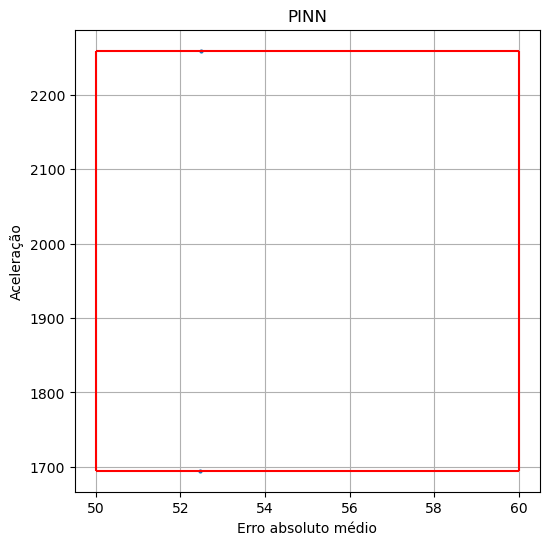

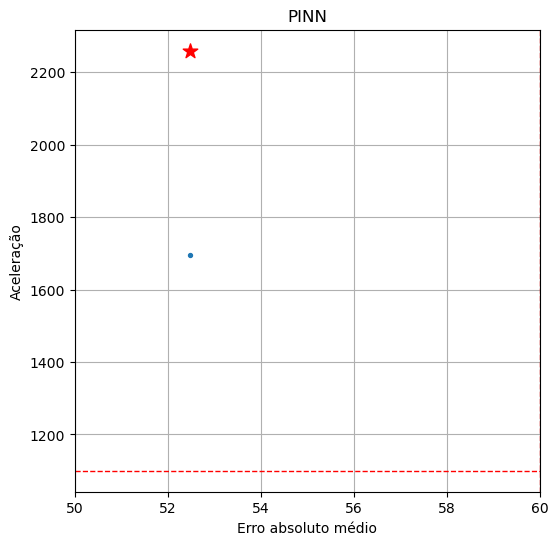

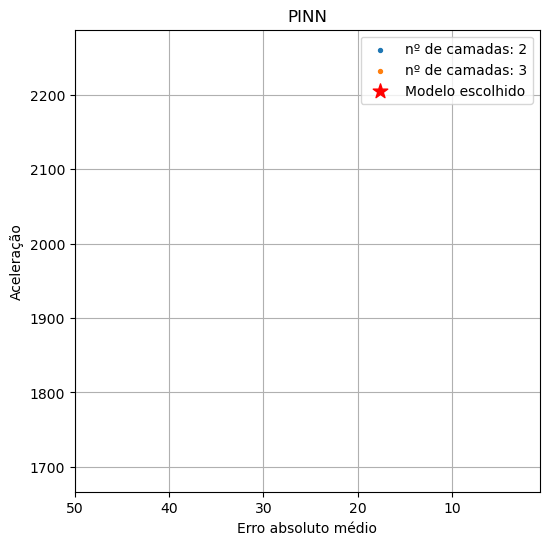

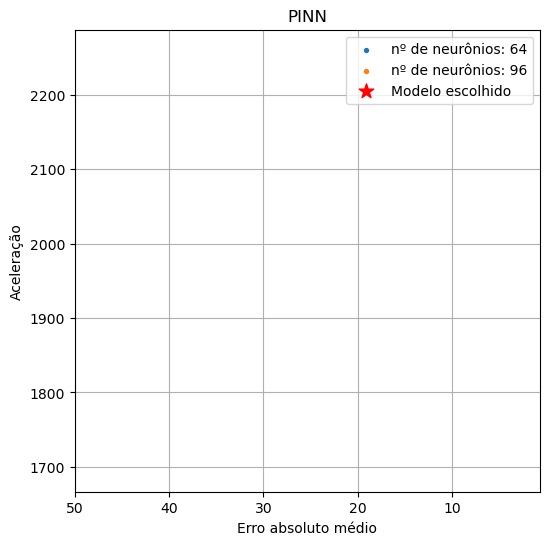

Arquitetura escolhida: ReLU--32__Tanh--32
Tipo de modelo: pinn
Best betas: 0.9__0.9999
Erro absoluto médio: 52.474340261753184
Erro absoluto máximo: 673.733603431703
Aceleração: 2259.088689764808 +/- 258.42673610922395
Tempo de treino: 85.3355528831482 +/- 0.6593561844921895
Tempo de teste: 0.002041912078857422 +/- 0.00031250567352196664

NN


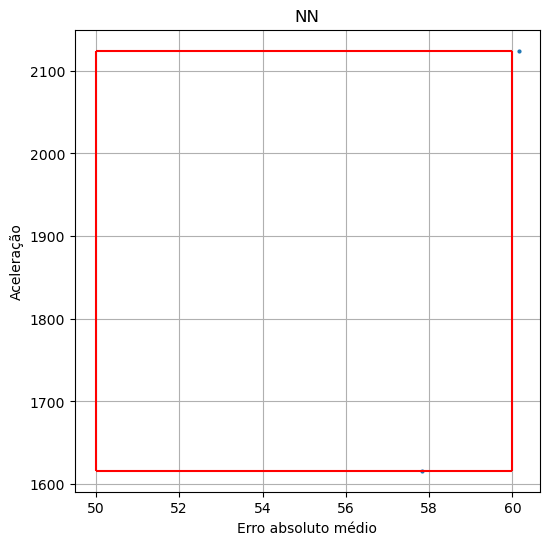

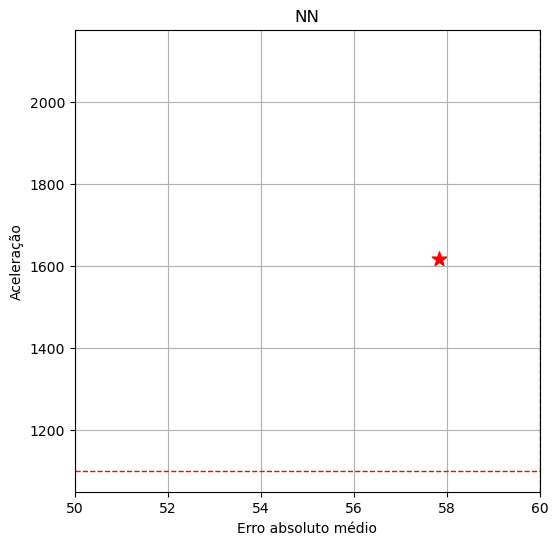

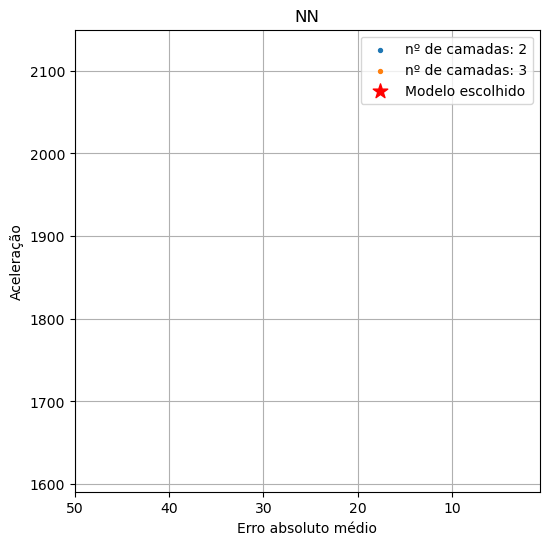

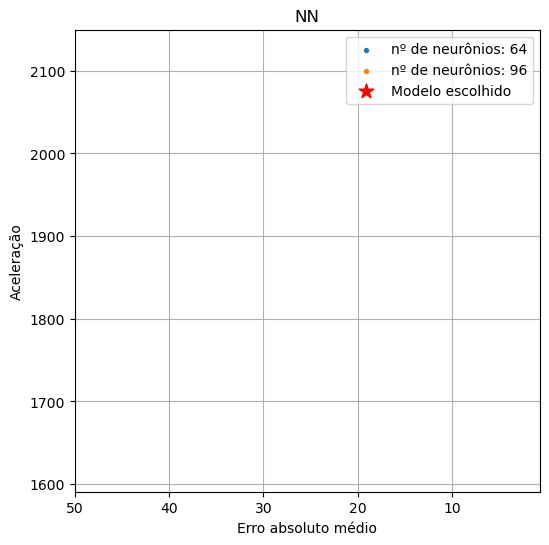

Arquitetura escolhida: ReLU--32__Tanh--32__ReLU--32
Tipo de modelo: nn
Best betas: 0.9__0.9999
Erro absoluto médio: 57.83698192190154
Erro absoluto máximo: 568.9299754819913
Aceleração: 1616.1038874523315 +/- 130.91907759553132
Tempo de treino: 12.468289804458617 +/- 0.09877081389092743
Tempo de teste: 0.0028265953063964845 +/- 0.00023429685026807713


In [19]:
import numpy as np
import matplotlib.pyplot as plt


error_col = "mean_ae"
speed_col = "mean_speed_up"

x_lim = (50, 60)

max_error_allowed = 60
min_speed_allowed = 1100

pinn_best_model = None
nn_best_model = None


for model_type in ["pinn", "nn"]:

    sub_results_df = results_df[
        results_df["model_type"] == model_type
    ].reset_index(drop=True)

    print("\n" + "=" * 30)
    print(model_type.upper())
    print("=" * 30)

    # --- Gráfico 1 ---
    fig1, ax1 = plt.subplots(figsize=(6, 6))

    ax1.scatter(
        sub_results_df[error_col],
        sub_results_df[speed_col],
        s=4,
    )

    ax1.hlines(
        max(sub_results_df[speed_col]),
        x_lim[0],
        x_lim[1],
        color="r",
    )

    ax1.hlines(
        min(sub_results_df[speed_col]),
        x_lim[0],
        x_lim[1],
        color="r",
    )

    ax1.vlines(
        x_lim[1],
        min(sub_results_df[speed_col]),
        max(sub_results_df[speed_col]),
        color="r",
    )

    ax1.vlines(
        x_lim[0],
        min(sub_results_df[speed_col]),
        max(sub_results_df[speed_col]),
        color="r",
    )

    ax1.set_xlabel("Erro absoluto médio")
    ax1.set_ylabel("Aceleração")
    ax1.set_title(model_type.upper())
    ax1.grid()
    plt.show()

    # --- Escolha do modelo ---
    choice_array = np.intersect1d(
        np.argwhere(np.array(sub_results_df[speed_col]) > min_speed_allowed),
        np.argwhere(np.array(sub_results_df[error_col]) < max_error_allowed),
    )

    if len(choice_array) == 0:
        print("Nenhum modelo satisfez os critérios definidos.")
        continue

    choice = choice_array[0]

    best_model = sub_results_df.iloc[choice]

    if model_type == "pinn":
        pinn_best_model = best_model

    elif model_type == "nn":
        nn_best_model = best_model

    # --- Gráfico 2 ---
    fig2, ax2 = plt.subplots(figsize=(6, 6))

    ax2.scatter(
        sub_results_df[error_col],
        sub_results_df[speed_col],
        s=8,
    )

    ax2.scatter(
        sub_results_df[error_col][choice],
        sub_results_df[speed_col][choice],
        c="r",
        marker="*",
        s=120,
    )

    ax2.axvline(
        max_error_allowed,
        color="r",
        linestyle="--",
        linewidth=1,
    )

    ax2.axhline(
        min_speed_allowed,
        color="r",
        linestyle="--",
        linewidth=1,
    )

    ax2.set_xlim(x_lim[0], x_lim[1])
    ax2.set_xlabel("Erro absoluto médio")
    ax2.set_ylabel("Aceleração")
    ax2.set_title(model_type.upper())
    ax2.grid()
    plt.show()

    # --- Gráfico 3 ---
    fig3, ax3 = plt.subplots(figsize=(6, 6))

    unique_n_layers = np.unique(sub_results_df.n_layers)

    for n_layers in unique_n_layers:

        sub_df = sub_results_df[
            sub_results_df.n_layers == int(n_layers)
        ]

        ax3.scatter(
            sub_df[error_col],
            sub_df[speed_col],
            s=8,
            label=f"nº de camadas: {int(n_layers)}",
        )

    ax3.scatter(
        best_model[error_col],
        best_model[speed_col],
        c="r",
        marker="*",
        s=120,
        label="Modelo escolhido",
    )

    ax3.set_xlabel("Erro absoluto médio")
    ax3.set_ylabel("Aceleração")
    ax3.set_xlim(x_lim[0], 0.7)
    ax3.set_title(model_type.upper())
    ax3.legend()
    ax3.grid()
    plt.show()

    # --- Gráfico 4 ---
    fig4, ax4 = plt.subplots(figsize=(6, 6))

    unique_n_neurons = np.unique(sub_results_df.n_neurons)

    for n_neurons in unique_n_neurons:

        sub_df = sub_results_df[
            sub_results_df.n_neurons == int(n_neurons)
        ]

        ax4.scatter(
            sub_df[error_col],
            sub_df[speed_col],
            s=8,
            label=f"nº de neurônios: {int(n_neurons)}",
        )

    ax4.scatter(
        best_model[error_col],
        best_model[speed_col],
        c="r",
        marker="*",
        s=120,
        label="Modelo escolhido",
    )

    ax4.set_xlabel("Erro absoluto médio")
    ax4.set_ylabel("Aceleração")
    ax4.set_xlim(x_lim[0], 0.7)
    ax4.set_title(model_type.upper())
    ax4.legend()
    ax4.grid()
    plt.show()

    # --- Prints ---
    print("Arquitetura escolhida:", best_model["arch_name"])
    print("Tipo de modelo:", best_model["model_type"])
    print("Best betas:", best_model["betas"])
    print("Erro absoluto médio:", best_model["mean_ae"])
    print("Erro absoluto máximo:", best_model["max_ae"])

    print(
        "Aceleração: {} +/- {}".format(
            best_model["mean_speed_up"],
            best_model["std_speed_up"],
        )
    )

    print(
        "Tempo de treino: {} +/- {}".format(
            best_model["mean_train_time"],
            best_model["std_train_time"],
        )
    )

    print(
        "Tempo de teste: {} +/- {}".format(
            best_model["mean_test_time"],
            best_model["std_test_time"],
        )
    )


PINN


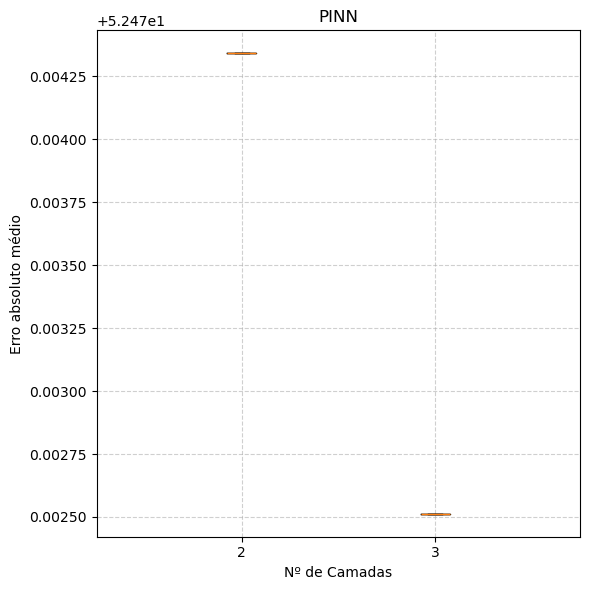

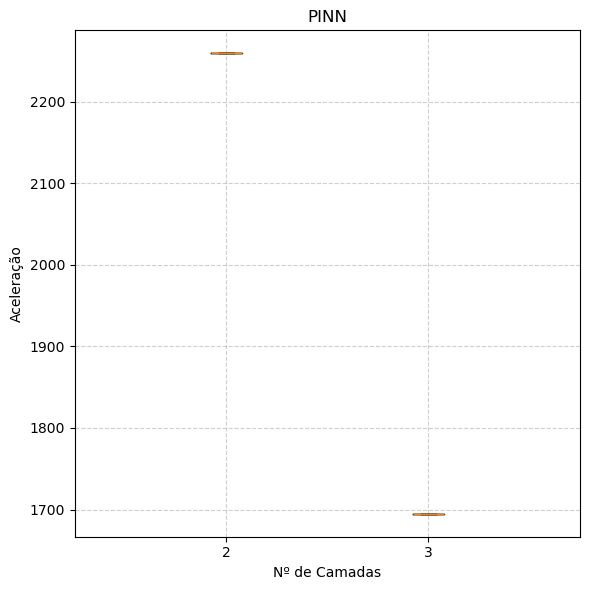

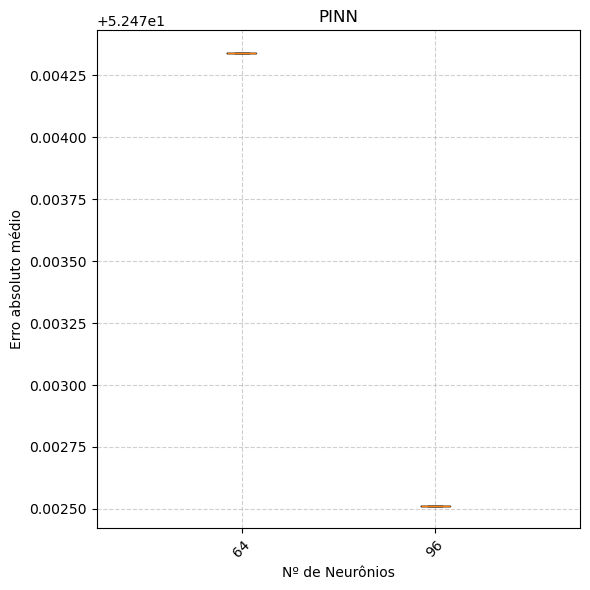

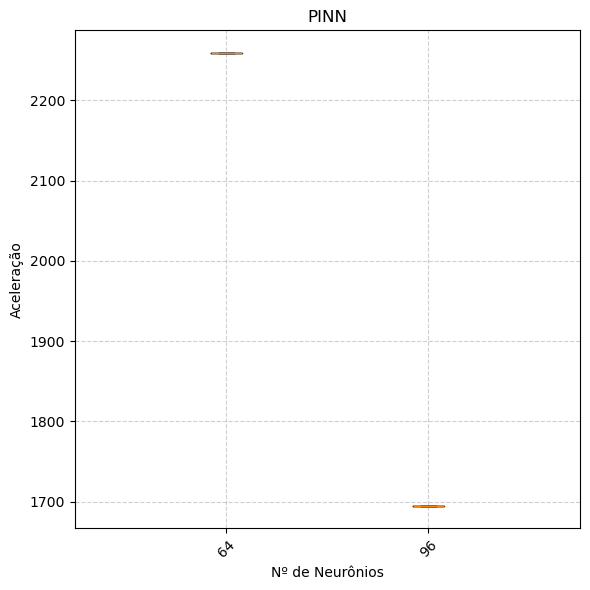


NN


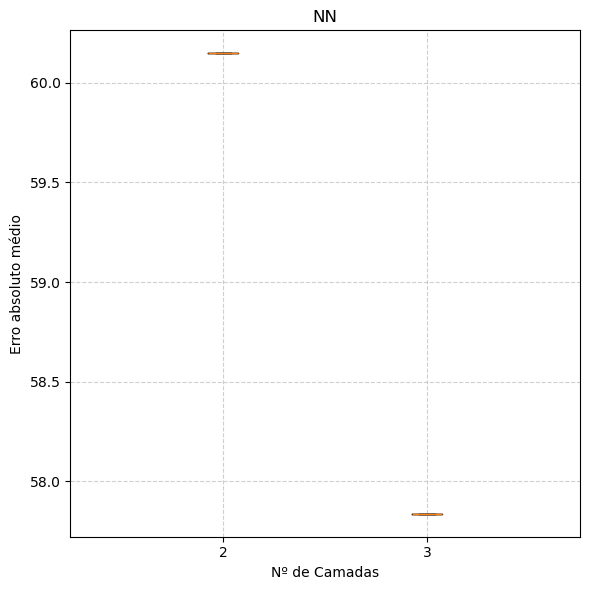

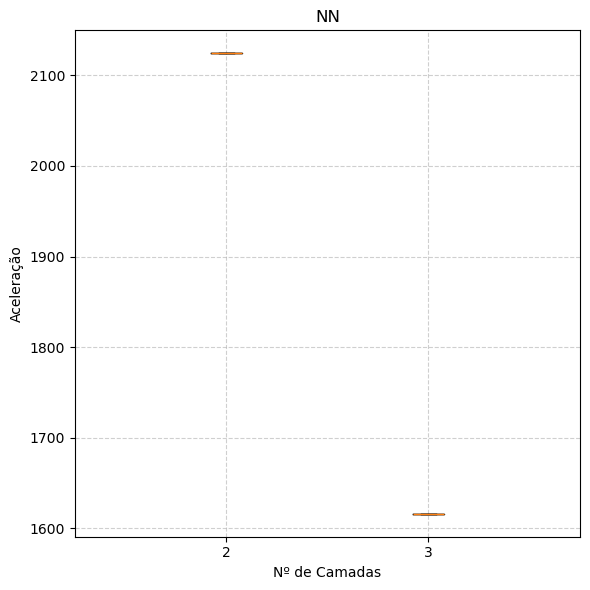

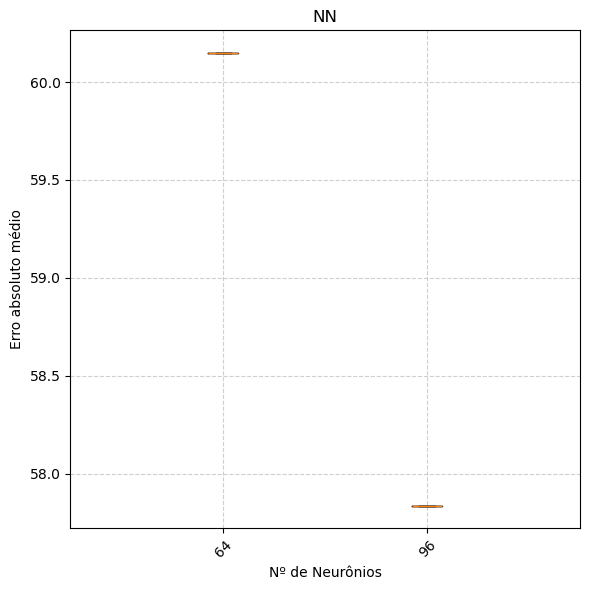

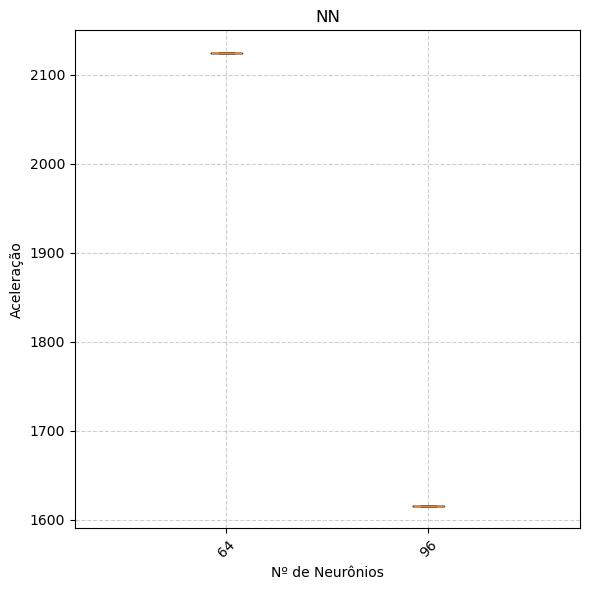

In [20]:
import matplotlib.pyplot as plt
import numpy as np


def set_axis_style(ax, labels, xlabel, ylabel):

    ax.set_xticks(np.arange(1, len(labels) + 1))

    ax.set_xticklabels(labels)

    ax.set_xlim(0.25, len(labels) + 0.75)

    ax.set_xlabel(xlabel)

    ax.set_ylabel(ylabel)

    ax.grid(True, linestyle="--", alpha=0.6)


# Novas colunas
error_col = "mean_ae"
speed_col = "mean_speed_up"


for model_type in ["pinn", "nn"]:

    sub_results_df = results_df[
        results_df["model_type"] == model_type
    ].copy()

    print("\n" + "=" * 30)
    print(model_type.upper())
    print("=" * 30)

    # =====================================================
    # Gráfico 1: erro absoluto médio por nº de camadas
    # =====================================================

    fig1, ax1 = plt.subplots(figsize=(6, 6))

    unique_n_layers = np.unique(sub_results_df.n_layers)

    collection = [
        sub_results_df[
            sub_results_df.n_layers == n
        ][error_col]
        for n in unique_n_layers
    ]

    ax1.boxplot(
        collection,
        positions=np.arange(1, len(unique_n_layers) + 1),
        showfliers=False,
    )

    set_axis_style(
        ax1,
        unique_n_layers,
        "Nº de Camadas",
        "Erro absoluto médio",
    )

    ax1.set_title(model_type.upper())

    plt.tight_layout()

    plt.show()

    # =====================================================
    # Gráfico 2: aceleração por nº de camadas
    # =====================================================

    fig2, ax2 = plt.subplots(figsize=(6, 6))

    collection = [
        sub_results_df[
            sub_results_df.n_layers == n
        ][speed_col]
        for n in unique_n_layers
    ]

    ax2.boxplot(
        collection,
        positions=np.arange(1, len(unique_n_layers) + 1),
        showfliers=False,
    )

    set_axis_style(
        ax2,
        unique_n_layers,
        "Nº de Camadas",
        "Aceleração",
    )

    ax2.set_title(model_type.upper())

    plt.tight_layout()

    plt.show()

    # =====================================================
    # Gráfico 3: erro absoluto médio por nº de neurônios
    # =====================================================

    fig3, ax3 = plt.subplots(figsize=(6, 6))

    unique_n_neurons = np.unique(sub_results_df.n_neurons)

    collection = [
        sub_results_df[
            sub_results_df.n_neurons == n
        ][error_col]
        for n in unique_n_neurons
    ]

    ax3.boxplot(
        collection,
        positions=np.arange(1, len(unique_n_neurons) + 1),
        showfliers=False,
    )

    set_axis_style(
        ax3,
        unique_n_neurons,
        "Nº de Neurônios",
        "Erro absoluto médio",
    )

    ax3.set_title(model_type.upper())

    plt.setp(ax3.get_xticklabels(), rotation=45)

    plt.tight_layout()

    plt.show()

    # =====================================================
    # Gráfico 4: aceleração por nº de neurônios
    # =====================================================

    fig4, ax4 = plt.subplots(figsize=(6, 6))

    collection = [
        sub_results_df[
            sub_results_df.n_neurons == n
        ][speed_col]
        for n in unique_n_neurons
    ]

    ax4.boxplot(
        collection,
        positions=np.arange(1, len(unique_n_neurons) + 1),
        showfliers=False,
    )

    set_axis_style(
        ax4,
        unique_n_neurons,
        "Nº de Neurônios",
        "Aceleração",
    )

    ax4.set_title(model_type.upper())

    plt.setp(ax4.get_xticklabels(), rotation=45)

    plt.tight_layout()

    plt.show()

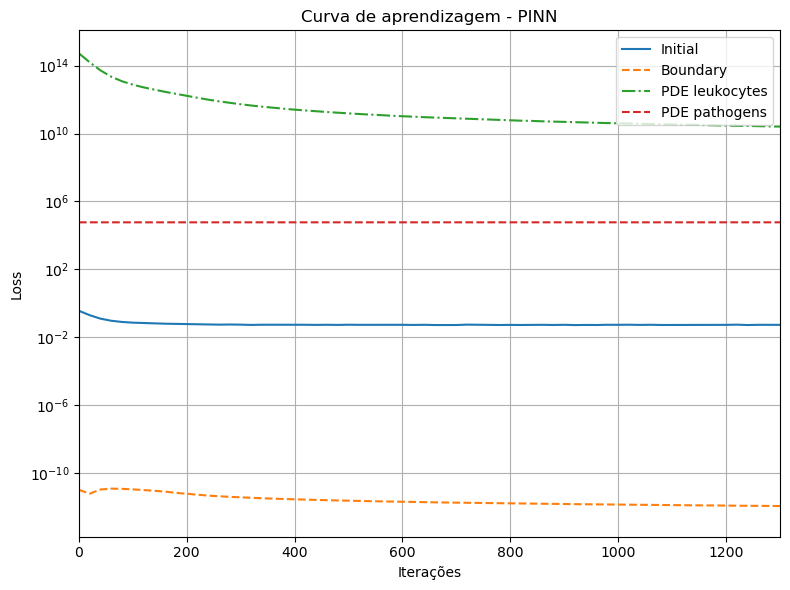

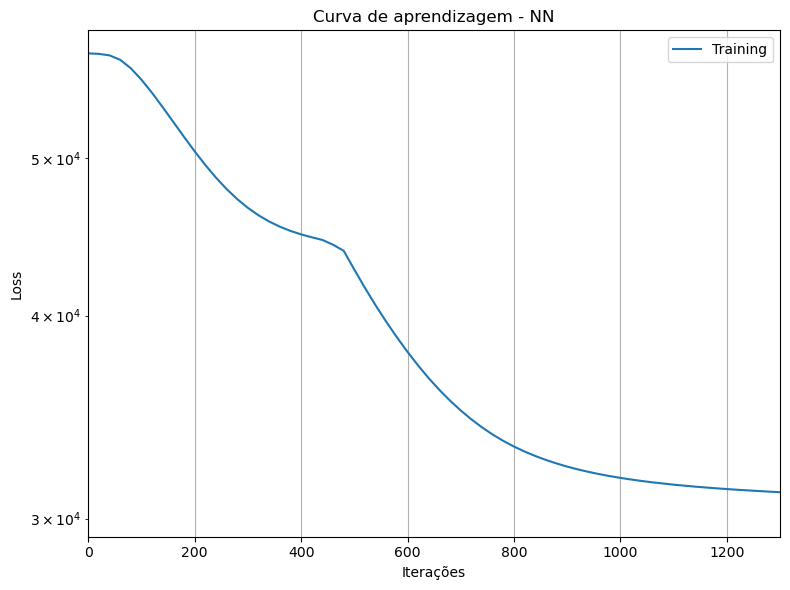

In [22]:
import os
import matplotlib.pyplot as plt
import pickle as pk


sampling_step = 20

best_models = {
    "pinn": pinn_best_model,
    "nn": nn_best_model,
}


for model_type, best_model in best_models.items():

    if best_model is None:
        print(f"Nenhum melhor modelo definido para {model_type.upper()}.")
        continue

    file_name = best_model["file"]

    # Ajusta o nome do arquivo de saída para o nome da curva de aprendizagem
    file_name = file_name.replace("pinn__output_", "pinn__")
    file_name = file_name.replace("nn__output_", "nn__")

    learning_curve_path = os.path.join(
        "learning_curves",
        file_name,
    )

    with open(learning_curve_path, "rb") as f:
        loss_dict = pk.load(f)

    fig = plt.figure(figsize=[8, 6])
    ax = fig.add_subplot(1, 1, 1)

    ax.set_xlabel("Iterações")
    ax.set_ylabel("Loss")
    ax.set_title(f"Curva de aprendizagem - {model_type.upper()}")

    if model_type == "pinn":

        labels = [
            "Initial",
            "Boundary",
            "PDE leukocytes",
            "PDE pathogens",
            "Validation",
        ]

        markers = [
            "-",
            "--",
            "-.",
            "--",
            "-.",
        ]

    else:

        labels = [
            "Training",
            "Validation",
        ]

        markers = [
            "-",
            "--",
        ]

    for loss, label, marker in zip(loss_dict, labels, markers):

        sampled_x = range(
            0,
            len(loss_dict[loss]),
            sampling_step,
        )

        sampled_y = loss_dict[loss][::sampling_step]

        ax.plot(
            sampled_x,
            sampled_y,
            marker,
            label=label,
        )

    ax.set_yscale("log")

    ax.grid()
    ax.legend()

    ax.set_xlim(0, 1300)

    plt.tight_layout()
    plt.show()

In [23]:
import pickle as pk
import json
from pinn import *

# Opening JSON file
with open("control_dicts/constant_properties.json", "r") as openfile:
    # Reading from json file
    constant_properties = json.load(openfile)

central_ini_cond = constant_properties["central_ini_cond"]

# Opening JSON file
with open("control_dicts/mesh_properties.json", "r") as openfile:
    # Reading from json file
    mesh_properties = json.load(openfile)

h = mesh_properties["h"]
k = mesh_properties["k"]
x_dom = mesh_properties["x_dom"]
y_dom = mesh_properties["y_dom"]
t_dom = mesh_properties["t_dom"]


Cl_list, Cp_list, speed_up_list = read_files("fvm_sim")

Cp_fvm, Cl_fvm, center, radius = format_array(Cp_list[0], Cl_list[0])

size_x, size_y, size_t = get_mesh_properties(x_dom, y_dom, t_dom, h, k)

with open("source_points/lymph_vessels.pkl", "rb") as f:
    leu_source_points = pk.load(f)

(
    initial_tc,
    center_x_tc,
    radius_tc,
    data_tc,
    target_tc,
    device,
) = allocates_training_mesh(
    t_dom,
    x_dom,
    size_t,
    size_x,
    center[0],
    central_ini_cond,
    radius,
    Cp_fvm,
    Cl_fvm,
)

Steps in time = 15000
Steps in space_x = 40
Steps in space_y = 1

device: cuda


In [24]:
from plots import (
    plot_comparison,
    plot_comparison_pinn,
    plot_comparison_contour,
)

import pickle as pk
import os


best_models = {
    "pinn": pinn_best_model,
    "nn": nn_best_model,
}


predictions = {}


for model_type, best_model in best_models.items():

    if best_model is None:

        print(f"Nenhum melhor modelo definido para {model_type.upper()}.")

        continue

    file_name = best_model["file"]

    # Ajusta o nome do arquivo
    prediction_file = file_name.replace(
        "output_",
        "prediction_",
    )

    prediction_path = os.path.join(
        "nn_sim",
        prediction_file,
    )

    with open(prediction_path, "rb") as f:

        prediction = pk.load(f)

    pred = prediction

    target_np = target_tc.cpu().detach().numpy()

    # =====================================================
    # Separação das variáveis
    # =====================================================

    Cl_pred_device, Cp_pred_device = np.split(
        pred,
        2,
        axis=1,
    )

    Cl_pred_np = Cl_pred_device.reshape(Cp_fvm.shape)

    Cp_pred_np = Cp_pred_device.reshape(Cp_fvm.shape)

    Cl_target_dev, Cp_target_dev = np.split(
        target_np,
        2,
        axis=1,
    )

    Cl_target_np = Cl_target_dev.reshape(Cp_fvm.shape)

    Cp_target_np = Cp_target_dev.reshape(Cp_fvm.shape)

    predictions[model_type] = {
        "Cl_pred": Cl_pred_np,
        "Cp_pred": Cp_pred_np,
        "Cl_target": Cl_target_np,
        "Cp_target": Cp_target_np,
    }

    print("\n" + "=" * 30)
    print(model_type.upper())
    print("=" * 30)

    print("Prediction loaded successfully.")

ValueError: cannot reshape array of size 120000 into shape (15000,40,1)

In [25]:
plot_comparison(
    size_t,
    size_x,
    t_dom,
    x_dom,
    Cp_fvm,
    Cl_fvm,
    predictions["pinn"]["Cp_pred"],
    predictions["pinn"]["Cl_pred"],
)

KeyError: 'pinn'

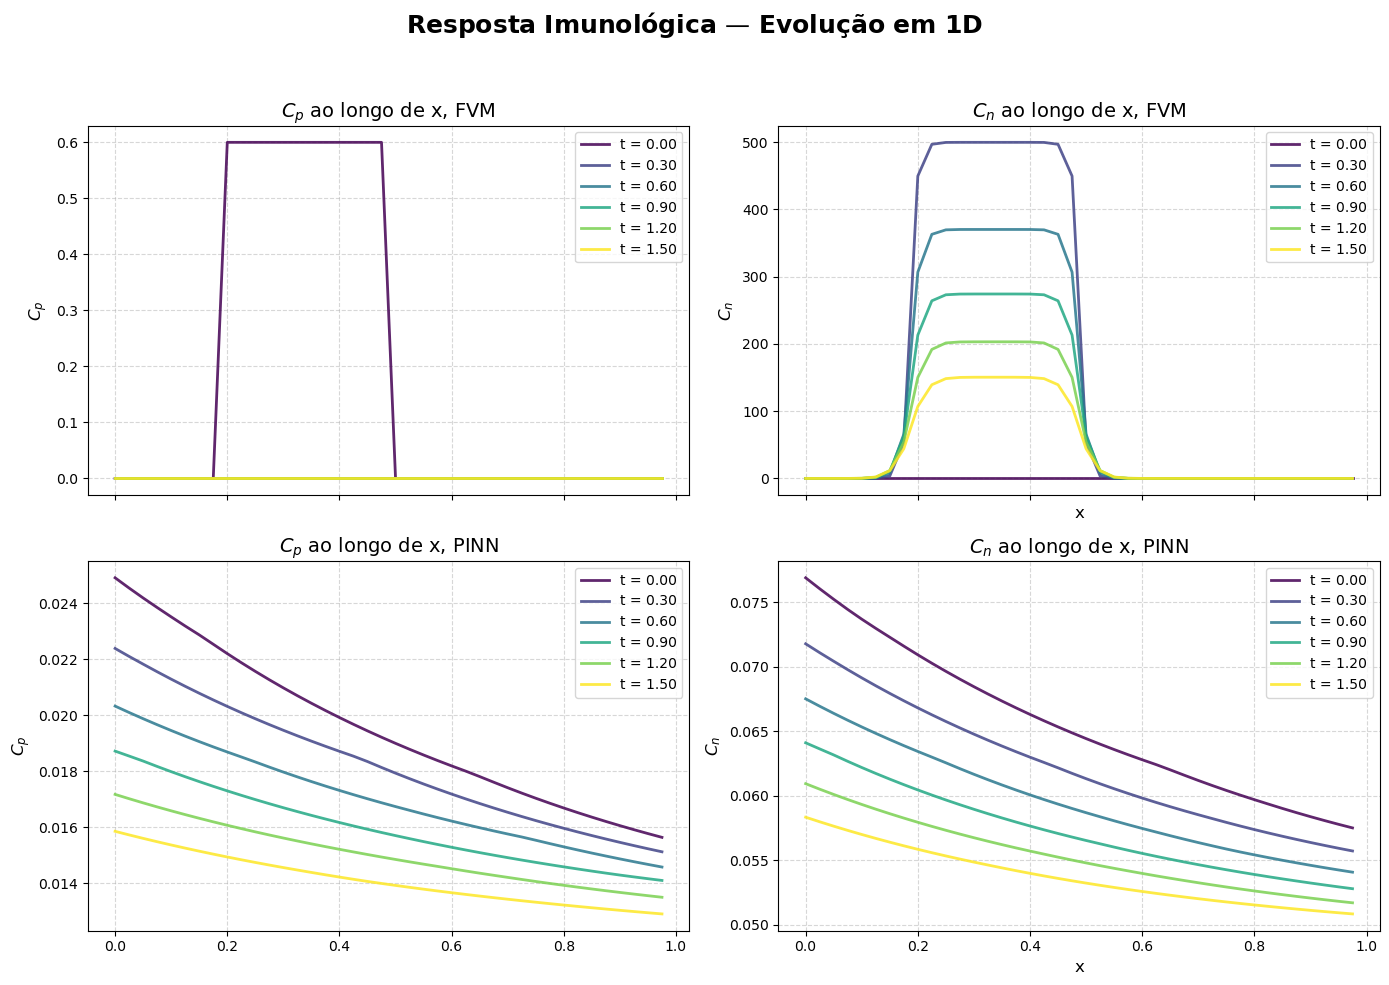

In [26]:
import torch
import numpy as np

# =====================================================
# Reconstrói target completo a partir do FVM
# =====================================================

target_np = np.concatenate(
    [
        Cl_fvm.reshape(-1, 1),
        Cp_fvm.reshape(-1, 1),
    ],
    axis=1,
)

# =====================================================
# PINN: carrega modelo escolhido e prediz malha completa
# =====================================================

pinn_model_path = "nn_parameters/" + pinn_best_model["file"]
pinn_model_path = pinn_model_path.replace("pinn__output_", "pinn__")
pinn_model_path = pinn_model_path.replace(".pkl", ".pt")

pinn_model = generate_model(
    pinn_best_model["arch_name"],
    2,
    2
).to(device)

pinn_model.load_state_dict(
    torch.load(
        pinn_model_path,
        map_location=device,
        weights_only=True,
    )
)

pinn_model.eval()

with torch.no_grad():
    pred_pinn = pinn_model(data_tc.to(device)).cpu().detach().numpy()

Cl_pinn_np, Cp_pinn_np = np.split(pred_pinn, 2, axis=1)

Cl_pinn_np = Cl_pinn_np.reshape(Cp_fvm.shape)
Cp_pinn_np = Cp_pinn_np.reshape(Cp_fvm.shape)

# =====================================================
# Plot PINN
# =====================================================

plot_comparison(
    size_t,
    size_x,
    t_dom,
    x_dom,
    Cp_fvm,
    Cl_fvm,
    Cp_pinn_np,
    Cl_pinn_np,
)

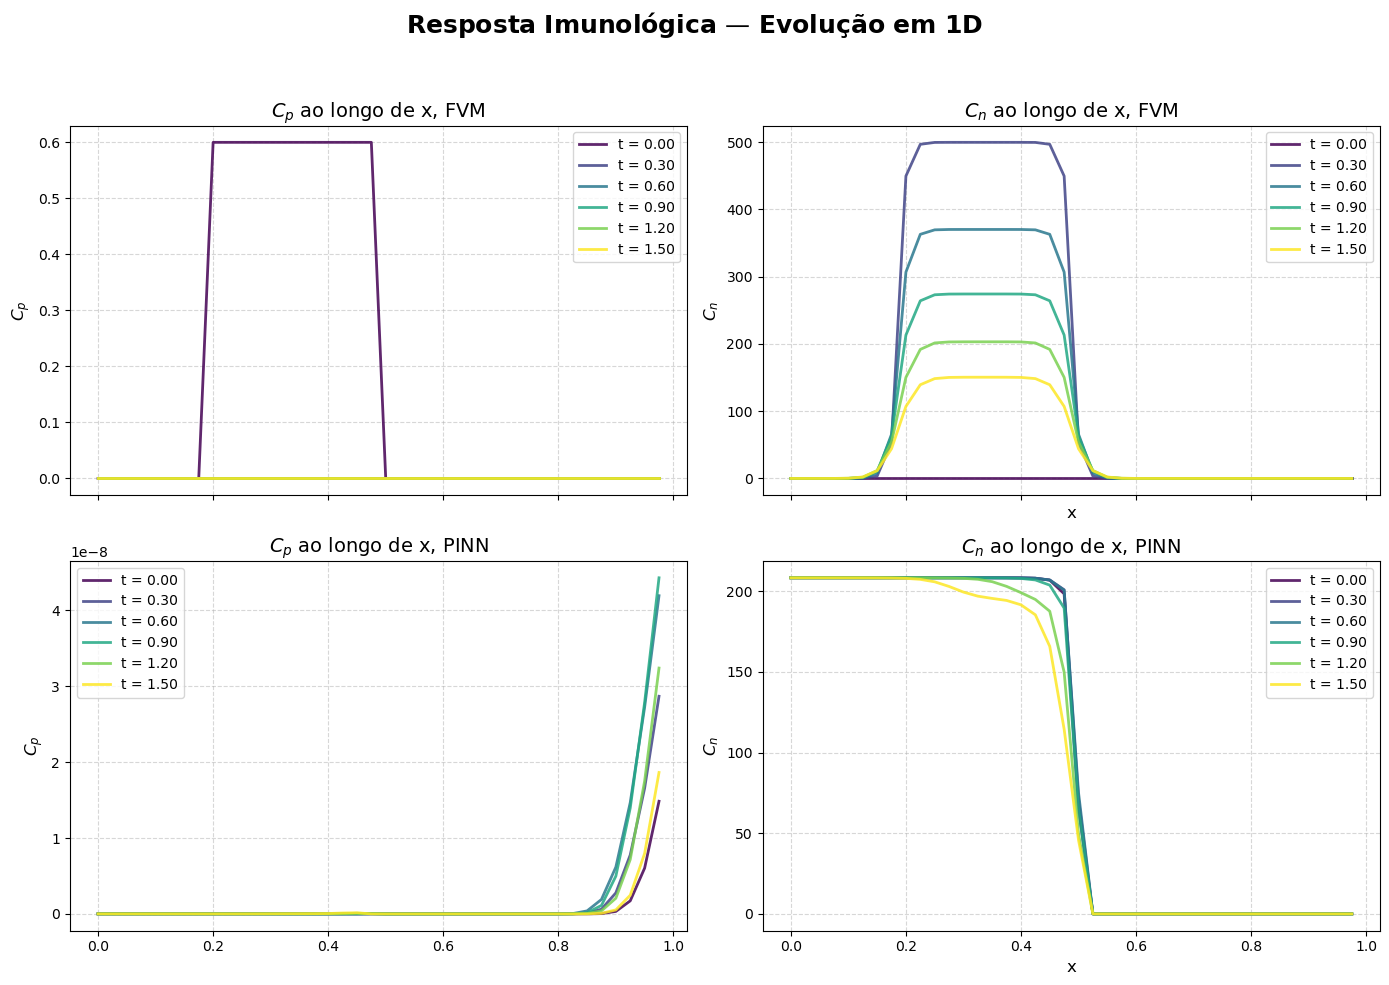

In [27]:
# =====================================================
# NN: carrega modelo escolhido e prediz malha completa
# =====================================================

nn_model_path = "nn_parameters/" + nn_best_model["file"]
nn_model_path = nn_model_path.replace("nn__output_", "nn__")
nn_model_path = nn_model_path.replace(".pkl", ".pt")

nn_model = generate_model(
    nn_best_model["arch_name"],
    2,
    2
).to(device)

nn_model.load_state_dict(
    torch.load(
        nn_model_path,
        map_location=device,
        weights_only=True,
    )
)

nn_model.eval()

with torch.no_grad():
    pred_nn = nn_model(data_tc.to(device)).cpu().detach().numpy()

Cl_nn_np, Cp_nn_np = np.split(pred_nn, 2, axis=1)

Cl_nn_np = Cl_nn_np.reshape(Cp_fvm.shape)
Cp_nn_np = Cp_nn_np.reshape(Cp_fvm.shape)

# =====================================================
# Plot NN
# =====================================================

plot_comparison(
    size_t,
    size_x,
    t_dom,
    x_dom,
    Cp_fvm,
    Cl_fvm,
    Cp_nn_np,
    Cl_nn_np,
)

## Samples analisys

In [17]:
result_list = glob("pinn_sim/comp_*")

print("numero de amostragens testadas: {}".format(len(result_list) / 2))

numero de amostragens testadas: 0.0


In [18]:
i = 0

results_dict = {}

for file in result_list:

    file_type, n_samples = file.split("/")[-1].replace(".pkl", "").split("_")[1:]

    if file_type == "metrics":
        with open(file, "rb") as f:
            aux_dict = pk.load(f)

        results_dict[i] = aux_dict

        i += 1

In [19]:
results_df = pd.DataFrame.from_dict(results_dict, orient="index").sort_values(
    by=["n_samples"]
)[1:]

results_df.tail()

KeyError: 'n_samples'

In [ ]:
import matplotlib.pyplot as plt
import pickle as pk

with open("learning_curves/comp.pkl", "rb") as f:
    loss_dict = pk.load(f)

fig = plt.figure(figsize=[8, 6])
# fig.suptitle("Curva de aprendizagem", fontsize=16)

ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel("Iterações")
ax.set_ylabel("RMSE")

sampling_step = 20  # change this to control how many points are plotted

labels = [
    "Perda de dados",
    "Perda de validação",
]

markers = [
    "-",
    "--",
]

for loss, label, m in zip(loss_dict, labels, markers):
    sampled_x = range(0, len(loss_dict[loss]), sampling_step)
    sampled_y = loss_dict[loss][::sampling_step]

    ax.plot(
        sampled_x,
        sampled_y,
        m,
        label=label,
    )

# ax.set_yscale("log")  # uncomment if needed
ax.grid()
ax.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(
    results_df["n_samples"], results_df["pinn_rmse"], marker="o", label="PINN RMSE"
)
plt.plot(results_df["n_samples"], results_df["pinn_mae"], marker="o", label="PINN MAE")
plt.plot(results_df["n_samples"], results_df["nn_rmse"], marker="s", label="RN RMSE")
plt.plot(results_df["n_samples"], results_df["nn_mae"], marker="s", label="RN MAE")
plt.xlabel("Numero de passos de tempo")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Plot
plt.figure(figsize=(8, 5))

# PINN with error bars
plt.errorbar(
    results_df["n_samples"],
    results_df["mean_pinn_time"],
    yerr=results_df["std_pinn_time"],
    fmt="-o",
    label="PINN Time",
    capsize=5,
    ms=4,
)

# NN with error bars
plt.errorbar(
    results_df["n_samples"],
    results_df["mean_nn_time"],
    yerr=results_df["std_nn_time"],
    fmt="-s",
    label="NN Time",
    capsize=5,
    ms=4,
)

# Final plot settings
plt.xlabel("Numero de passos de tempo")
plt.ylabel("Tempo de treino (s)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
samples_choice = 1500

file = "pinn_sim/comp_output_{:d}.pkl".format(samples_choice)

with open(file, "rb") as f:
    choice = pk.load(f)

In [ ]:
pred_pinn = choice["pred_pinn"]
pred_nn = choice["pred_nn"]
target = choice["target"]

In [ ]:
Cl_pinn_device, Cp_pinn_device = np.split(pred_pinn, 2, axis=1)

Cl_pinn_np = Cl_pinn_device.reshape(Cp_fvm.shape)

Cp_pinn_np = Cp_pinn_device.reshape(Cp_fvm.shape)

Cl_nn_device, Cp_nn_device = np.split(pred_nn, 2, axis=1)

Cl_nn_np = Cl_nn_device.reshape(Cp_fvm.shape)

Cp_nn_np = Cp_nn_device.reshape(Cp_fvm.shape)

In [ ]:
t_np = np.linspace(t_dom[0], t_dom[-1], num=size_t, endpoint=True, dtype=np.float32)
x_np = np.linspace(x_dom[0], x_dom[-1], num=size_x, endpoint=False, dtype=np.float32)
time_plot = np.linspace(0, size_t - 1, num=60, endpoint=True, dtype=int)

source_index = np.argwhere(leu_source_points[:, 0] == 1).ravel()

import os
import numpy as np
import matplotlib.pyplot as plt

# Diretório onde as imagens serão salvas
output_dir = "anims"
os.makedirs(output_dir, exist_ok=True)

# Lista dos dados e seus rótulos
datasets = [
    (Cp_fvm, Cl_fvm, "FVM"),
    (Cp_pinn_np, Cl_pinn_np, "PINN"),
    (Cp_nn_np, Cl_nn_np, "NN"),
]

# Calcula os limites globais de Cp e Cn para cada modelo
y_limits = []  # Lista de tuplas: (cp_min, cp_max, cn_min, cn_max)
for Cp_data, Cn_data, _ in datasets:
    cp_min, cp_max = np.min(Cp_data), np.max(Cp_data)
    cn_min, cn_max = np.min(Cn_data), np.max(Cn_data)
    y_limits.append((cp_min, cp_max, cn_min, cn_max))

# Iterar sobre cada passo de tempo especificado
for time_idx, time_inst in enumerate(time_plot):
    t_val = t_np[time_inst]

    for model_idx, (Cb_data, Cn_data, model_name) in enumerate(datasets):
        cp_min, cp_max, cn_min, cn_max = y_limits[model_idx]

        for data, ylabel in zip([Cb_data, Cn_data], ["$C_p$", "$C_n$"]):
            fig, ax = plt.subplots(figsize=(6, 4))

            # Plot da curva para o instante de tempo atual
            ax.plot(
                x_np,
                data[time_inst].squeeze(),
                label=f"t = {t_val:.2f}",
                color="blue",
                linewidth=2,
                alpha=0.9,
            )

            # Plot das fontes
            ax.scatter(
                x_np[source_index],
                np.zeros(source_index.shape),
                color="red",
                label="Fontes",
                s=40,
                marker="x",
            )

            # Escala fixa com base nos valores do método
            if ylabel == "$C_p$":
                ax.set_ylim([cp_min, cp_max])
            else:
                ax.set_ylim([cn_min, cn_max])

            ax.set_xlabel("x", fontsize=12)
            ax.set_ylabel(ylabel, fontsize=12)
            ax.legend()
            ax.grid(True, linestyle="--", alpha=0.5)
            plt.tight_layout()

            # Salva a imagem
            filename = f"{output_dir}/plot_{model_name}_{ylabel.replace('$', '')}_t{time_idx}.png"
            plt.savefig(filename, dpi=300)
            plt.close(fig)

In [ ]:
t_np = np.linspace(t_dom[0], t_dom[-1], num=size_t, endpoint=True, dtype=np.float32)
x_np = np.linspace(x_dom[0], x_dom[-1], num=size_x, endpoint=False, dtype=np.float32)
time_plot = np.linspace(0, size_t - 1, num=6, endpoint=True, dtype=int)

colors = plt.cm.viridis(np.linspace(0, 1, len(time_plot)))
source_index = np.argwhere(leu_source_points[:, 0] == 1).ravel()

# Lista dos dados e seus rótulos
datasets = [
    (Cp_fvm, Cl_fvm),
    (Cp_pinn_np, Cl_pinn_np),
    (Cp_nn_np, Cl_nn_np),
]

# Laço para cada conjunto de dados (FVM, PINN, NN)
for model_idx, (Cb_data, Cn_data) in enumerate(datasets):
    for data, ylabel in zip([Cb_data, Cn_data], ["$C_p$", "$C_n$"]):
        fig, ax = plt.subplots(figsize=(6, 4))
        for i, time_inst in enumerate(time_plot):
            ax.plot(
                x_np,
                data[time_inst].squeeze(),
                label=f"t = {t_np[time_inst]:.2f}",
                color=colors[i],
                linewidth=2,
                alpha=0.85,
            )

        ax.scatter(
            x_np[source_index],
            np.zeros(source_index.shape),
            color="red",
            label="Fontes",
            s=40,
            marker="x",
        )

        ax.set_xlabel("x", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

In [ ]:
titles = [
    "$C_p$ FVM",
    "$C_p$ PINN",
    "Erro Absoluto - $C_p$",
    "$C_l$ FVM",
    "$C_l$ PINN",
    "Erro Absoluto - $C_l$",
]

plot_comparison_contour(
    size_t,
    size_x,
    t_dom,
    x_dom,
    Cp_target_np,
    Cl_target_np,
    Cp_pinn_np,
    Cl_pinn_np,
)

In [ ]:
titles = [
    "$C_p$ FVM",
    "$C_p$ RN",
    "Erro Absoluto - $C_p$",
    "$C_l$ FVM",
    "$C_l$ RN",
    "Erro Absoluto - $C_l$",
]

plot_comparison_contour(
    size_t, size_x, t_dom, x_dom, Cp_target_np, Cl_target_np, Cp_nn_np, Cl_nn_np
)

In [19]:
import torch
import torch.nn as nn

class AdaptiveLossWeights(nn.Module):
    def __init__(self, n_terms: int):
        super().__init__()
        # começa tudo com peso igual
        self.log_vars = nn.Parameter(torch.zeros(n_terms, dtype=torch.float32))

    def forward(self, losses):
        """
        losses: lista ou tupla de tensores escalares
        """
        total_loss = 0.0
        weighted_losses = []

        for i, loss_i in enumerate(losses):
            precision = torch.exp(-self.log_vars[i])
            weighted = precision * loss_i + self.log_vars[i]
            total_loss = total_loss + weighted
            weighted_losses.append(weighted)

        return total_loss, weighted_losses

In [20]:
class PINN(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=32, out_dim=2, n_hidden=4):
        super().__init__()

        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [21]:
def gradients(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]

In [22]:
mse_loss = nn.MSELoss()

def compute_pinn_losses(model, x_data, y_data, x_ic, y_ic, x_bc, x_f):
    """
    x_data: pontos com dados supervisionados
    y_data: alvo nos pontos com dados
    x_ic: pontos da condição inicial
    y_ic: alvo da condição inicial
    x_bc: pontos da condição de contorno
    x_f: pontos internos para resíduo físico
    """

    # -------------------------
    # Loss de dados
    # -------------------------
    pred_data = model(x_data)
    loss_data = mse_loss(pred_data, y_data)

    # -------------------------
    # Loss de condição inicial
    # -------------------------
    pred_ic = model(x_ic)
    loss_ic = mse_loss(pred_ic, y_ic)

    # -------------------------
    # Loss de contorno
    # Exemplo: derivada espacial zero
    # -------------------------
    x_bc.requires_grad_(True)
    pred_bc = model(x_bc)

    cp_bc = pred_bc[:, 0:1]
    cl_bc = pred_bc[:, 1:2]

    grad_bc = gradients(pred_bc, x_bc)
    dcp_dx_bc = grad_bc[:, 0:1]
    dcl_dx_bc = grad_bc[:, 0:1]  # ajuste aqui se precisar separar melhor

    loss_bc = mse_loss(dcp_dx_bc, torch.zeros_like(dcp_dx_bc)) + \
              mse_loss(dcl_dx_bc, torch.zeros_like(dcl_dx_bc))

    # -------------------------
    # Loss da PDE
    # Exemplo genérico
    # -------------------------
    x_f.requires_grad_(True)
    pred_f = model(x_f)

    cp = pred_f[:, 0:1]
    cl = pred_f[:, 1:2]

    grad_cp = gradients(cp, x_f)
    grad_cl = gradients(cl, x_f)

    dcp_dx = grad_cp[:, 0:1]
    dcp_dt = grad_cp[:, 1:2]

    dcl_dx = grad_cl[:, 0:1]
    dcl_dt = grad_cl[:, 1:2]

    d2cp_dx2 = gradients(dcp_dx, x_f)[:, 0:1]
    d2cl_dx2 = gradients(dcl_dx, x_f)[:, 0:1]

    # Exemplo artificial de resíduo
    # Ajuste para suas equações reais
    residual_cp = dcp_dt - 0.01 * d2cp_dx2 + cp * cl
    residual_cl = dcl_dt - 0.02 * d2cl_dx2 - cp

    loss_pde = mse_loss(residual_cp, torch.zeros_like(residual_cp)) + \
               mse_loss(residual_cl, torch.zeros_like(residual_cl))

    return loss_data, loss_ic, loss_bc, loss_pde

In [23]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Domínio
x_min, x_max = 0.0, 1.0
t_min, t_max = 0.0, 1.5

# Quantidades de pontos
N_data = 1000
N_ic = 200
N_bc = 200
N_f = 2000

# -----------------------------------
# Função exemplo para gerar y_data
# Troque isso pelos seus dados do MVF
# -----------------------------------
def reference_solution(x, t):
    Cp = torch.exp(-20 * (x - 0.5)**2) * torch.exp(-t)
    Cl = torch.sin(torch.pi * x)**2 * (1 - torch.exp(-5 * t))
    return torch.cat([Cp, Cl], dim=1)

# -----------------------------------
# x_data e y_data
# pontos internos com dados supervisionados
# -----------------------------------
x = torch.rand(N_data, 1) * (x_max - x_min) + x_min
t = torch.rand(N_data, 1) * (t_max - t_min) + t_min

x_data = torch.cat([x, t], dim=1)
y_data = reference_solution(x, t)

# -----------------------------------
# x_ic e y_ic
# condição inicial: t = 0
# -----------------------------------
x_ic_space = torch.rand(N_ic, 1) * (x_max - x_min) + x_min
t_ic = torch.zeros(N_ic, 1)

x_ic = torch.cat([x_ic_space, t_ic], dim=1)
y_ic = reference_solution(x_ic_space, t_ic)

# -----------------------------------
# x_bc
# condição de contorno: x = 0 e x = 1
# -----------------------------------
t_bc = torch.rand(N_bc, 1) * (t_max - t_min) + t_min

x_left = torch.zeros(N_bc // 2, 1)
x_right = torch.ones(N_bc - N_bc // 2, 1)

t_left = t_bc[:N_bc // 2]
t_right = t_bc[N_bc // 2:]

x_bc_left = torch.cat([x_left, t_left], dim=1)
x_bc_right = torch.cat([x_right, t_right], dim=1)

x_bc = torch.cat([x_bc_left, x_bc_right], dim=0)

# -----------------------------------
# x_f
# pontos internos para resíduo da EDP
# -----------------------------------
x_f_space = torch.rand(N_f, 1) * (x_max - x_min) + x_min
t_f = torch.rand(N_f, 1) * (t_max - t_min) + t_min

x_f = torch.cat([x_f_space, t_f], dim=1)

# Envia tudo para device
x_data = x_data
y_data = y_data
x_ic = x_ic
y_ic = y_ic
x_bc = x_bc
x_f = x_f

print("x_data:", x_data.shape)
print("y_data:", y_data.shape)
print("x_ic:", x_ic.shape)
print("y_ic:", y_ic.shape)
print("x_bc:", x_bc.shape)
print("x_f:", x_f.shape)

x_data: torch.Size([1000, 2])
y_data: torch.Size([1000, 2])
x_ic: torch.Size([200, 2])
y_ic: torch.Size([200, 2])
x_bc: torch.Size([200, 2])
x_f: torch.Size([2000, 2])


In [26]:
import torch.optim as optim

model = PINN()

n_epochs = 5000

adaptive_weights = AdaptiveLossWeights(n_terms=4).to(device)

optimizer = optim.Adam(
    list(model.parameters()) + list(adaptive_weights.parameters()),
    lr=1e-3
)

for epoch in range(n_epochs):
    optimizer.zero_grad()

    loss_data, loss_ic, loss_bc, loss_pde = compute_pinn_losses(
        model,
        x_data, y_data,
        x_ic, y_ic,
        x_bc, x_f
    )

    total_loss, weighted_losses = adaptive_weights(
        [loss_data, loss_ic, loss_bc, loss_pde]
    )

    total_loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        log_vars = adaptive_weights.log_vars.detach().cpu().numpy()
        print(f"Epoch {epoch}")
        print(f"  total_loss = {total_loss.item():.6e}")
        print(f"  loss_data  = {loss_data.item():.6e}")
        print(f"  loss_ic    = {loss_ic.item():.6e}")
        print(f"  loss_bc    = {loss_bc.item():.6e}")
        print(f"  loss_pde   = {loss_pde.item():.6e}")
        print(f"  log_vars   = {log_vars}")

Epoch 0
  total_loss = 4.120620e-01
  loss_data  = 2.905773e-01
  loss_ic    = 1.135351e-01
  loss_bc    = 1.981082e-04
  loss_pde   = 7.751578e-03
  log_vars   = [-0.001 -0.001 -0.001 -0.001]
Epoch 500
  total_loss = -1.792532e+00
  loss_data  = 7.765406e-02
  loss_ic    = 4.034421e-02
  loss_bc    = 2.073168e-04
  loss_pde   = 6.035533e-03
  log_vars   = [-0.49842593 -0.5000694  -0.5015912  -0.5008689 ]
Epoch 1000
  total_loss = -3.926866e+00
  loss_data  = 1.794305e-02
  loss_ic    = 6.805217e-03
  loss_bc    = 1.196121e-04
  loss_pde   = 8.423784e-03
  log_vars   = [-1.0107182  -1.0139126  -1.0010324  -0.99636304]
Epoch 1500
  total_loss = -5.891388e+00
  loss_data  = 1.771220e-02
  loss_ic    = 7.132754e-03
  loss_bc    = 1.727579e-03
  loss_pde   = 3.982521e-03
  log_vars   = [-1.518563  -1.5216492 -1.5009263 -1.4931077]
Epoch 2000
  total_loss = -7.811628e+00
  loss_data  = 1.659003e-02
  loss_ic    = 6.634956e-03
  loss_bc    = 1.682396e-04
  loss_pde   = 3.792481e-03
  log_var

In [28]:
import torch
import matplotlib.pyplot as plt

model.eval()

# grid para visualização
Nx = 100
Nt = 100

x = torch.linspace(0, 1, Nx)
t = torch.linspace(0, 1.5, Nt)

X, T = torch.meshgrid(x, t, indexing="ij")

x_test = torch.cat([
    X.reshape(-1, 1),
    T.reshape(-1, 1)
], dim=1)

with torch.no_grad():
    y_pred = model(x_test)

Cp_pred = y_pred[:, 0].reshape(Nx, Nt).cpu()
Cl_pred = y_pred[:, 1].reshape(Nx, Nt).cpu()

X_np = X.cpu()
T_np = T.cpu()

In [33]:
with torch.no_grad():
    y_ref = reference_solution(
        x_test[:, 0:1].cpu(),
        x_test[:, 1:2].cpu()
    )

Cp_ref = y_ref[:, 0].reshape(Nx, Nt)
Cl_ref = y_ref[:, 1].reshape(Nx, Nt)

Cp_error = torch.abs(Cp_ref - Cp_pred)
Cl_error = torch.abs(Cl_ref - Cl_pred)

rmse_cp = torch.sqrt(torch.mean((Cp_ref - Cp_pred) ** 2))
mae_cp = torch.mean(torch.abs(Cp_ref - Cp_pred))

rmse_cl = torch.sqrt(torch.mean((Cl_ref - Cl_pred) ** 2))
mae_cl = torch.mean(torch.abs(Cl_ref - Cl_pred))

print(f"RMSE Cp: {rmse_cp.item():.6e}")
print(f"MAE  Cp: {mae_cp.item():.6e}")

print(f"RMSE Cl: {rmse_cl.item():.6e}")
print(f"MAE  Cl: {mae_cl.item():.6e}")

RMSE Cp: 9.646764e-02
MAE  Cp: 8.613902e-02
RMSE Cl: 2.141927e-01
MAE  Cl: 1.715525e-01


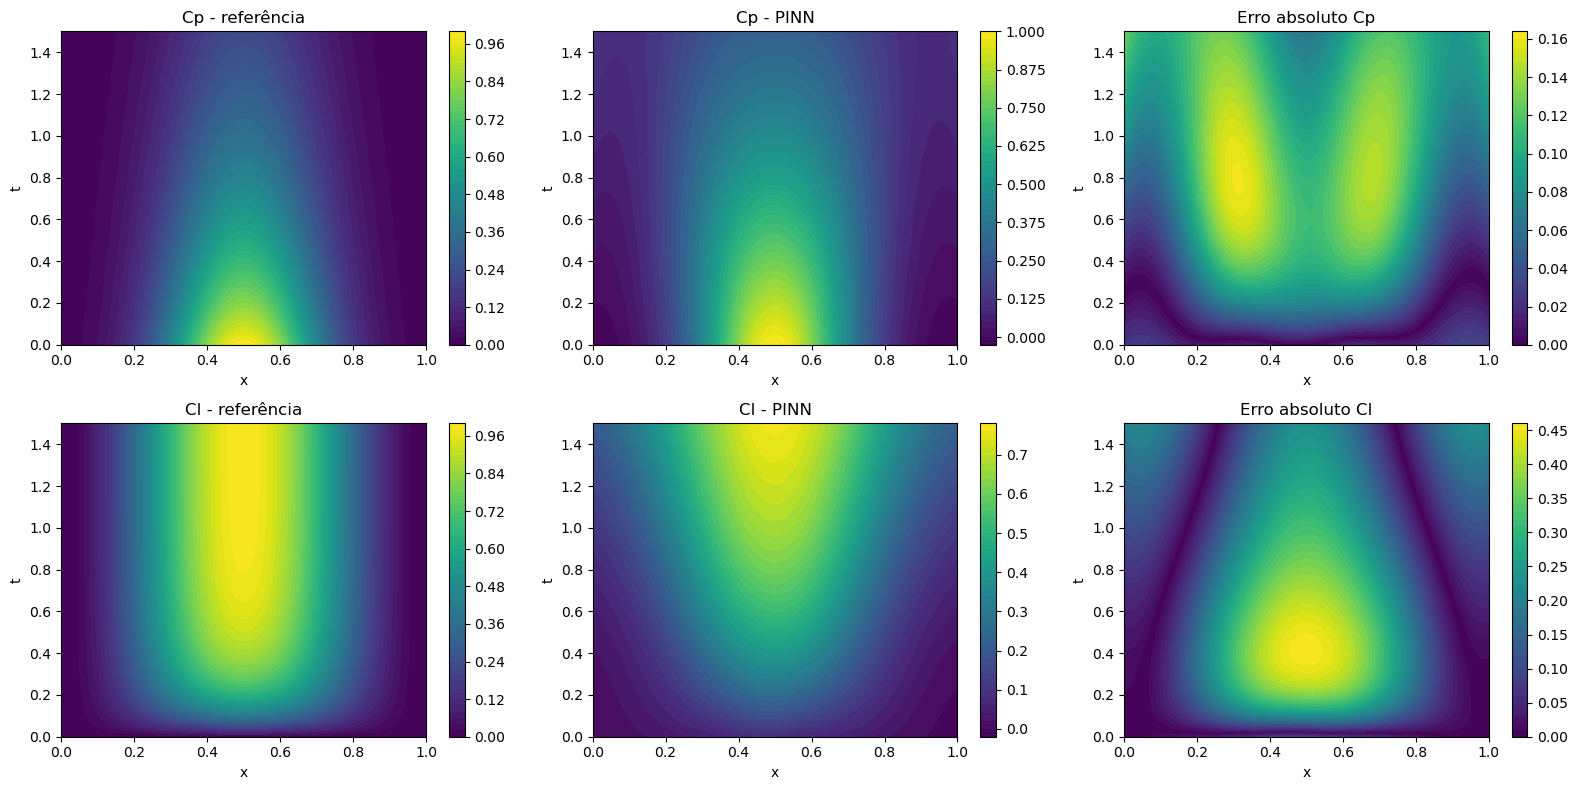

In [35]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

plots = [
    (Cp_ref,  "Cp - referência",      axs[0, 0]),
    (Cp_pred, "Cp - PINN",            axs[0, 1]),
    (Cp_error,"Erro absoluto Cp",     axs[0, 2]),
    (Cl_ref,  "Cl - referência",      axs[1, 0]),
    (Cl_pred, "Cl - PINN",            axs[1, 1]),
    (Cl_error,"Erro absoluto Cl",     axs[1, 2]),
]

for data, title, ax in plots:
    im = ax.contourf(X_np, T_np, data, levels=50)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()